# Mentoring 1 - Fraud Analytics
---
Mohammad Rifqi Zein \
Mentoring Session - Job Preparation Program - Pacmann AI

In [2]:
# Load package
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import DummyClassifier from Sklearn Library
from sklearn.dummy import DummyClassifier

## 1. Case Description
---

- You are a data scientist in the insurance division of the automotive industry.
- However, your company might suffer loss because fraudulent claims are being processed, leading to financial instability.
- To minimize the loss and increase profitability, your goal is to detect fraudulent claims early in the process and reduce the impact of false claims on the company's revenue.
- As a data scientist, you want to create a rule-based system to detect fraud. By defining specific rules and thresholds based on domain expertise, you can identify suspicious claims that deviate from normal patterns, flagging them for further investigation and helping to prevent fraudulent claims from being approved.
- The dataset: [Vehicle Insurance Claim Fraud Detection](https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection)

## 2. Dataset Description
---

|Column Name|Definition|
|:--|:--|
|`Month`|Month of the incident|
|`WeekOfMonth`|Week of the month the incident occurred|
|`DayOfWeek`|Day of the week the incident occurred|
|`Make`|The manufacturer of the vehicle involved in the claim|
|`AccidentArea`|Urban classification of the area where the accident occurred (e.g., urban, suburban, rural)|
|`DayOfWeekClaimed`|Day of the week the claim was made|
|`MonthClaimed`|Month the claim was made|
|`WeekOfMonthClaimed`|Week of the month the claim was made|
|`Sex`|Driver's gender|
|`MaritalStatus`|Marital status of the driver|
|`Age`|Age of the driver|
|`Fault`|Who was found to be at fault in the accident|
|`PolicyType`|The type of insurance policy|
|`VehicleCategory`|The category of the vehicle (e.g., sedan, sport)|
|`VehiclePrice`|Original price of the vehicle involved in the accident|
|`FraudFound_P`|Whether the claim was determined to be fraudulent or not|
|`PolicyNumber`|Unique insurance policy identifier|
|`RepNumber`|Unique identifier of the claims adjuster who handled each claim|
|`Deductible`|Amount the insured must pay before the insurer begins paying for repairs|
|`DriverRating`|Driver's rating|
|`Days_Policy_Accident`|Days between policy inception and the reported date of accident|
|`Days_Policy_Claim`|The number of days since the policy was issued until the claim was made|
|`PastNumberOfClaims`|Number of prior claims on the insured's policy|
|`AgeOfVehicle`|The age of the vehicle involved in the claim|
|`AgeOfPolicyHolder`|Age group of the policyholder|
|`PoliceReportField`|Whether a police report was filed at the time of the accident|
|`WitnessPresent`|Whether any witnesses were present at the time of the accident|
|`AgentType`|External/Internal|
|`NumberOfSuppliments`|Number of additional payments issued on the claim|
|`AddressChange_Claim`|Time between most recent policyholder change of address and date the claim was reported|
|`NumberOfCars`|Number of vehicles insured under the policy|
|`Year`|Year of the incident|
|`BasePolicy`|Base policy type (liability-only or full coverage)|

## 3. The Tools
---

You can use python to do this exercise.

## 4. Your Task
---

**Importing Data**

Pertama, data akan disiapkan terlebih dahulu.

In [12]:
# read dataset function
def read_data(path):
    """
    Reads a CSV file at the given path, removes any duplicate rows,
    and returns its contents as a pandas DataFrame.

    Parameters
    ----------
    path : str
        The sample data input path (csv format)

    Return
    ------
    df : pd.DataFrame
        The sample data input
    """
    # Read data
    df = pd.read_csv(path)

    # Validate
    print('Data shape:', df.shape)

    return df

In [13]:
# Dataset name / Path
path = 'fraud_oracle.csv'

# Read the data
df = read_data(path = path)
df.head()

Data shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [14]:
# Check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

**Splitting Data**

Kemudian, kita akan melakukan splitting data terlebih dahulu agar tidak terjadi data leaking ketika training dan evaluasi model.

**Split Input & Output**

In [18]:
# function split input and output
def split_input_output(data, target_column):
    """
    Function to split input (x) and output (y)

    Parameters
    ----------
    data : pd.DataFrame
        The sample data input

    target_column : str
        The output column name

    Return
    ------
    X : pd.DataFrame
        input data

    y : pd.DataFrame
        output data
    """
    X = data.drop(columns = target_column)
    y = data[target_column]

    # Validate
    print('X shape:', X.shape)
    print('y shape :', y.shape)

    return X, y

In [19]:
# Split input x and output y
X, y = split_input_output(data = df,
                          target_column = "FraudFound_P")

# Show 5 first rows of input
X.head()

X shape: (15420, 32)
y shape : (15420,)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [20]:
# Show 5 first rows of output
y.head()

0    0
1    0
2    0
3    0
4    0
Name: FraudFound_P, dtype: int64

In [21]:
# check data dimension
n_samples, n_features = X.shape

# print number samples and features
print(f"Number of samples  : {n_samples}")
print(f"Number of features : {n_features}")

Number of samples  : 15420
Number of features : 32


In [22]:
# check data features name
features_names = X.columns

# print name of features
print(f"name of features : {features_names}")

name of features : Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'PolicyNumber', 'RepNumber', 'Deductible',
       'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')


**Split Train, Valid, and Test Data**

In [24]:
from sklearn.model_selection import train_test_split

def split_train_valid_test(X, y, test_size, valid_size, stratify, random_state=42):
    """
    Split data into train & test

    Parameters
    ----------
    X : pd.DataFrame
        The input data

    y : pd.Series
        The output data

    test_size : float
        The proportion of number of test data to total data

    valid_size : float
        The proportion of number of validation data to total data

    stratify : pd.Series
        Reference to stratify the splitting

    random_state : int, default=42
        The random seed, for reproducibility

    Returns
    -------
    X_train : pd.DataFrame
        The input train data

    X_test : pd.DataFrame
        The input test data

    y_train : pd.Series
        The output train data

    y_test : pd.Series
        The output test data
    """
    # Split the data
    X_train, X_not_train, y_train, y_not_train = train_test_split(
        X,
        y,
        test_size = test_size + valid_size,
        stratify = stratify,
        random_state = random_state
    )

    # Then, split valid and test from not_train
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_not_train,
        y_not_train,
        test_size = valid_size/(test_size + valid_size),
        stratify = y_not_train,
        random_state = random_state
    )

    # Validate
    print('X train shape:', X_train.shape)
    print('y train shape:', y_train.shape)
    print('X valid shape :', X_valid.shape)
    print('y valid shape :', y_valid.shape)
    print('X test shape :', X_test.shape)
    print('y test shape :', y_test.shape)

    return X_train, X_valid, X_test, y_train, y_valid, y_test


In [25]:
# Run the code
splitted_data = split_train_valid_test(
    X = X,
    y = y,
    test_size = 0.2,
    valid_size = 0.2,
    stratify = y,
    random_state = 42
)

X_train, X_valid, X_test, y_train, y_valid, y_test = splitted_data

X train shape: (9252, 32)
y train shape: (9252,)
X valid shape : (3084, 32)
y valid shape : (3084,)
X test shape : (3084, 32)
y test shape : (3084,)


**Create EDA Dataset**

In [27]:
# create EDA dataset
eda_df = pd.concat([X_train, y_train],
                   axis=1)
eda_df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,FraudFound_P
2839,Jan,1,Tuesday,Pontiac,Urban,Thursday,Jan,1,Male,Married,...,51 to 65,No,No,External,more than 5,no change,1 vehicle,1994,Liability,0
5783,Mar,2,Friday,Pontiac,Urban,Friday,Mar,2,Male,Married,...,36 to 40,No,No,External,none,no change,1 vehicle,1994,All Perils,0
10425,Jan,1,Tuesday,Pontiac,Rural,Monday,Jan,2,Male,Married,...,36 to 40,No,No,External,none,no change,1 vehicle,1995,Collision,0
10966,Jan,1,Thursday,Toyota,Urban,Wednesday,Jan,2,Male,Married,...,51 to 65,No,No,External,none,no change,1 vehicle,1995,Liability,0
14520,Jul,2,Sunday,Dodge,Rural,Tuesday,Jul,2,Female,Single,...,31 to 35,No,No,External,more than 5,no change,1 vehicle,1996,Liability,0


In [28]:
# Print train set shape after concat
print('eda_df shape:', eda_df.shape)

eda_df shape: (9252, 33)


Data inilah yang akan digunakan untuk menjawab pertanyaan-pertanyaan di bawah ini.

## Question 1

Determine the percentage of claims identified as fraudulent based on fraud indicators in the dataset (e.g., using the column FraudFound_P). This includes calculating: 
- The total number of claims
- The number of claims flagged as fraudulent (where FraudFound_P == 1)
- The proportion of fraudulent claims is expressed as a percentage.

In [32]:
# Find the total number of claims
total_claim = eda_df.shape[0]
total_claim

9252

In [33]:
# Find the number of claims flagged as fraudulent (where FraudFound_P == 1)
fraud_claim = eda_df["FraudFound_P"].value_counts()[1]
fraud_claim

554

In [34]:
# Find the proportion of fraudulent claims is expressed as a percentage.
fraud_claim_ratio = eda_df["FraudFound_P"].value_counts(normalize = True)[1] * 100
fraud_claim_ratio

5.9878945092952875

In [35]:
print(f"""
The total number of claims in this dataset is {total_claim}.
The number of claims flagged as fraudulent (where FraudFound_P == 1) is {fraud_claim}.
Thus, the proportion of fraudulent claims is {fraud_claim_ratio:.2f}% of total number of claims.
""")


The total number of claims in this dataset is 9252.
The number of claims flagged as fraudulent (where FraudFound_P == 1) is 554.
Thus, the proportion of fraudulent claims is 5.99% of total number of claims.



## Question 2

One of the analyses needed is to compare the characteristics of fraudulent and normal insurance claims to derive insights that can help the insurance company understand the nature of these claims better.
- Numerical Variables
  - Variables (5 total): Age, WeekofMonth, etc (Add up to five additional variables that could enhance insights into claims behavior)
  - Statistical Measures: Mean, Median, std, Min, and Max
- Categorical Variables
  - Variables (5  total): VehiclePrice, Make, Fault, Days_Policy_Accident, etc [Add up to five additional variables that could enhance insights into claims behavior)
  - Statistical Measures: frequency and proportion

 \
Comparative Analysis: Perform all the analysis above in three segments:
- Fraudulent Claims Only
- Normal Claims Only
- Combined View of Both Claims

### Numerical Variables

Numerical variables yang digunakan adalah `Age`, `WeekOfMonth`, `WeekOfMonthClaimed`, `Deductible`, `DriverRating`.

In [40]:
eda_df.pivot_table(index=['FraudFound_P'],
                   values=['Age', 'WeekOfMonth', 'WeekOfMonthClaimed', 'Deductible', 'DriverRating'],
                   margins=True,
                   aggfunc=['mean','median','std','min','max']).T

FraudFound_P                        0           1         All
mean   Age                  39.910324   38.938628   39.852140
       Deductible          408.162796  411.552347  408.365759
       DriverRating          2.499770    2.498195    2.499676
       WeekOfMonth           2.794206    2.718412    2.789667
       WeekOfMonthClaimed    2.699816    2.682310    2.698768
median Age                  38.000000   38.000000   38.000000
       Deductible          400.000000  400.000000  400.000000
       DriverRating          3.000000    3.000000    3.000000
       WeekOfMonth           3.000000    3.000000    3.000000
       WeekOfMonthClaimed    3.000000    3.000000    3.000000
std    Age                  13.427322   14.830319   13.516529
       Deductible           46.171640   48.224629   46.301417
       DriverRating          1.120358    1.101124    1.119157
       WeekOfMonth           1.282444    1.258657    1.281091
       WeekOfMonthClaimed    1.257710    1.241307    1.256675
min    Age                   0.000000    0.000000    0.000000
       Deductible          300.000000  400.000000  300.000000
       DriverRating          1.000000    1.000000    1.000000
       WeekOfMonth           1.000000    1.000000    1.000000
       WeekOfMonthClaimed    1.000000    1.000000    1.000000
max    Age                  80.000000   80.000000   80.000000
       Deductible          700.000000  700.000000  700.000000
       DriverRating          4.000000    4.000000    4.000000
       WeekOfMonth           5.000000    5.000000    5.000000
       WeekOfMonthClaimed    5.000000    5.000000    5.000000

Dari hasil di atas dapat terlihat bahwa:
- Terdapat anomali umur (Age == 0) baik di fraudulent claim maupun normal claim.
- Nilai minimum deductible untuk fraudulent claim (400) lebih tinggi daripada normal claim (300).
- Selain itu, tidak terlihat adanya perbedaan yang signifikan.

### Categorical Variables

Categorical variables yang digunakan adalah `VehiclePrice`, `Make`, `Fault`, `BasePolicy`, `Days_Policy_Accident`.

In [44]:
# VehiclePrice by frequency
pd.crosstab(index=eda_df['FraudFound_P'],
            columns=eda_df['VehiclePrice'],
            margins = True)

VehiclePrice,20000 to 29000,30000 to 39000,40000 to 59000,60000 to 69000,less than 20000,more than 69000,All
FraudFound_P,,,,,,,
0,4598,2007,273,51,590,1179,8698
1,246,110,17,3,59,119,554
All,4844,2117,290,54,649,1298,9252


In [45]:
# VehiclePrice by proportion (in percent)
pd.crosstab(index=eda_df['FraudFound_P'],
            columns=eda_df['VehiclePrice'],
            normalize='columns',
            margins = True)*100

VehiclePrice,20000 to 29000,30000 to 39000,40000 to 59000,60000 to 69000,less than 20000,more than 69000,All
FraudFound_P,,,,,,,
0,94.921552,94.803968,94.137931,94.444444,90.909091,90.832049,94.012105
1,5.078448,5.196032,5.862069,5.555556,9.090909,9.167951,5.987895


Jika dilihat dari harga kendaraan, dapat dilihat bahwa:
- Frekuensi fraudulent claim tertinggi yaitu kendaraan yang bernilai 20000 to 29000, more than 69000, lalu 30000 to 39000
- Sementara frekuensi normal claim tertinggi yaitu kendaraan yang bernilai 20000 to 29000, 30000 to 39000, lalu more than 69000.
- Proporsi fraudulent claim untuk kendaraan yang bernilai more than 69000 kira-kira 1.5 kali lipat lebih tinggi dari harga kendaraan yang lain.
- Proporsi fraudulent claim untuk kendaraan yang bernilai less than 20000 juga kira-kira 1.5 kali lipat lebih tinggi dari harga kendaraan yang lain.

In [47]:
# Make by frequency
pd.crosstab(index=eda_df['FraudFound_P'],
            columns=eda_df['Make'],
            margins = True)

Make,Accura,BMW,Chevrolet,Dodge,Ferrari,Ford,Honda,Jaguar,Lexus,Mazda,Mecedes,Mercury,Nisson,Pontiac,Porche,Saab,Saturn,Toyota,VW,All
FraudFound_P,,,,,,,,,,,,,,,,,,,,
0,251,10,934,59,1,254,1586,1,1,1323,1,47,20,2180,3,58,30,1773,166,8698
1,40,0,57,1,0,23,104,0,0,69,0,4,1,127,0,8,5,112,3,554
All,291,10,991,60,1,277,1690,1,1,1392,1,51,21,2307,3,66,35,1885,169,9252


In [48]:
# Make by proportion (in percent)
pd.crosstab(index=eda_df['FraudFound_P'],
            columns=eda_df['Make'],
            normalize='columns',
            margins = True)*100

Make,Accura,BMW,Chevrolet,Dodge,Ferrari,Ford,Honda,Jaguar,Lexus,Mazda,Mecedes,Mercury,Nisson,Pontiac,Porche,Saab,Saturn,Toyota,VW,All
FraudFound_P,,,,,,,,,,,,,,,,,,,,
0,86.254296,100.0,94.248234,98.333333,100.0,91.696751,93.846154,100.0,100.0,95.043103,100.0,92.156863,95.238095,94.495015,100.0,87.878788,85.714286,94.058355,98.224852,94.012105
1,13.745704,0.0,5.751766,1.666667,0.0,8.303249,6.153846,0.0,0.0,4.956897,0.0,7.843137,4.761905,5.504985,0.0,12.121212,14.285714,5.941645,1.775148,5.987895


Jika dilihat dari merek kendaraan, dapat dilihat bahwa:
- Frekuensi fraudulent claim tertinggi yaitu kendaraan Pontiac, Toyota, lalu Honda.
- Frekuensi normal claim tertinggi juga kendaraan Pontiac, Toyota, lalu Honda.
- Secara frekuensi, tidak ada yang bersifat anomali dari merek kendaraan.
- Proporsi fraudulent claim untuk kendaraan yang bermerek Saab, Saturn, dan Accura lebih dari 2 kali lipat dibandingkan proporsi rata-rata (5.99%).
- Namun, frekuensi ketiga mobil tersebut jauh lebih sedikit dibandingkan merek mobil yang lain.

In [50]:
# Fault by frequency
pd.crosstab(index=eda_df['FraudFound_P'],
            columns=eda_df['Fault'],
            margins = True)

Fault,Policy Holder,Third Party,All
FraudFound_P,,,
0,6214,2484,8698
1,535,19,554
All,6749,2503,9252


In [51]:
# Fault by proportion (in percent)
pd.crosstab(index=eda_df['FraudFound_P'],
            columns=eda_df['Fault'],
            normalize='columns',
            margins = True)*100

Fault,Policy Holder,Third Party,All
FraudFound_P,,,
0,92.0729,99.240911,94.012105
1,7.9271,0.759089,5.987895


Jika dilihat dari pihak yang bersalah, dapat dilihat bahwa:
- Frekuensi fraudulent claim tertinggi yaitu ketika pihak pemegang polis (Policy Holder) bersalah.
- Frekuensi normal claim tertinggi juga ketika pihak pemegang polis (Policy Holder) bersalah.
- Secara frekuensi, tidak ada yang bersifat anomali dari pihak yang bersalah.
- Namun, secara proporsi fraudulent claim untuk Policy Holder (7.93%) 10 kali lipat lebih tinggi daripada Third Party (0.76%)

In [53]:
# BasePolicy by frequency
pd.crosstab(index=eda_df['FraudFound_P'],
            columns=eda_df['BasePolicy'],
            margins = True)

BasePolicy,All Perils,Collision,Liability,All
FraudFound_P,,,,
0,2366,3354,2978,8698
1,266,266,22,554
All,2632,3620,3000,9252


In [54]:
# BasePolicy by proportion (in percent)
pd.crosstab(index=eda_df['FraudFound_P'],
            columns=eda_df['BasePolicy'],
            normalize='columns',
            margins = True)*100

BasePolicy,All Perils,Collision,Liability,All
FraudFound_P,,,,
0,89.893617,92.651934,99.266667,94.012105
1,10.106383,7.348066,0.733333,5.987895


Jika dilihat dari tipe cakupan polis, dapat dilihat bahwa:
- Frekuensi fraudulent claim tertinggi yaitu untuk polis All Perils dan Collision.
- Sementara frekuensi normal claim tertinggi yaitu untuk polis Collision dan Liability.
- Proporsi fraudulent claim untuk polis Liability jauh lebih kecil dibandingkan jenis polis lainnya.

In [56]:
# Days_Policy_Accident by frequency
pd.crosstab(index=eda_df['FraudFound_P'],
            columns=eda_df['Days_Policy_Accident'],
            margins = True)

Days_Policy_Accident,1 to 7,15 to 30,8 to 15,more than 30,none,All
FraudFound_P,,,,,,
0,6,26,32,8610,24,8698
1,1,3,4,542,4,554
All,7,29,36,9152,28,9252


In [57]:
# Days_Policy_Accident by proportion (in percent)
pd.crosstab(index=eda_df['FraudFound_P'],
            columns=eda_df['Days_Policy_Accident'],
            normalize='columns',
            margins = True)*100

Days_Policy_Accident,1 to 7,15 to 30,8 to 15,more than 30,none,All
FraudFound_P,,,,,,
0,85.714286,89.655172,88.888889,94.077797,85.714286,94.012105
1,14.285714,10.344828,11.111111,5.922203,14.285714,5.987895


Jika dilihat dari jangka waktu dari pembelian polis ke kecelakaan, dapat dilihat bahwa:
- Frekuensi fraudulent claim tertinggi yaitu di kategori more than 30.
- Frekuensi normal claim tertinggi juga di kategori more than 30.
- Secara frekuensi, tidak ada yang bersifat anomali dari jangka waktunya.
- Secara proporsi fraudulent claim untuk jangka waktu yang lain lebih tinggi dari proporsi untuk kategori more than 30.
- Namun, frekuensi kategori tersebut jauh lebih sedikit dibandingkan kategori more than 30.

## Question 3

Perform exploratory data analyses, Using the vehicle insurance claims dataset: 
- Create up to two visualizations to examine the distribution of numerical variables that are relevant for analyzing fraudulent cases. Use the fraudulent status as the hue to differentiate the distributions. What insights can you draw from your analysis regarding fraud detection?
- Create up to two time series visualizations to analyze trends over time. Use fraudulent status as the hue to differentiate the patterns. What trends or anomalies do you observe over time in relation to fraud detection?
- Create up to five visualizations to compare categorical variables. Provide insights from your analysis using these charts to understand fraudulent detection patterns.

### Visualizations for Numerical Variables

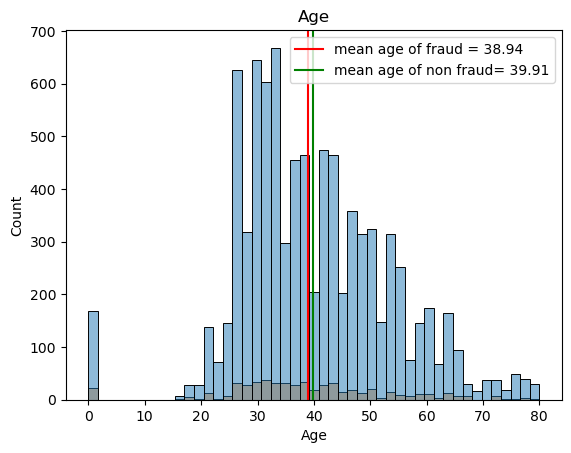

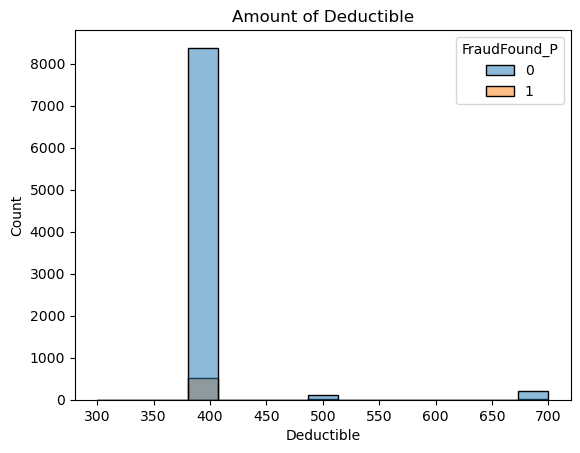

In [62]:
# Visualize the Ages
sns.histplot(data = eda_df,
             x = "Age",
             hue = "FraudFound_P")

fraud_age = eda_df[eda_df["FraudFound_P"] == 1]["Age"]
nonfraud_age = eda_df[eda_df["FraudFound_P"] == 0]["Age"]

plt.axvline([fraud_age.mean()],
            color = "r",
            label = f"mean age of fraud = {np.round(fraud_age.mean(), 2)}")

plt.axvline([nonfraud_age.mean()],
            color = "g",
            label = f"mean age of non fraud= {np.round(nonfraud_age.mean(), 2)}")

plt.legend()
plt.title("Age")
plt.show()

# Visualize the Deductible
sns.histplot(data = eda_df,
            x = "Deductible",
            hue = "FraudFound_P")

plt.title("Amount of Deductible")
plt.show()

Dari hasil di atas semakin memperkuat hasil dari pertanyaan sebelumnya bahwa:
- Terdapat anomali umur (Age == 0) baik di fraudulent claim maupun normal claim.
- Rata-rata umur untuk fraudulent claim sedikit lebih muda dibandingkan normal claim, meskipun tidak terlalu berbeda secara signifikan.
- Selain itu, bentuk distribusi umur mirip seperti distribusi normal.
- Nilai deductible baik untuk normal claim maupun fraudulent claim memiliki frekuensi paling banyak di nilai 400.

### Time Series Visualizations

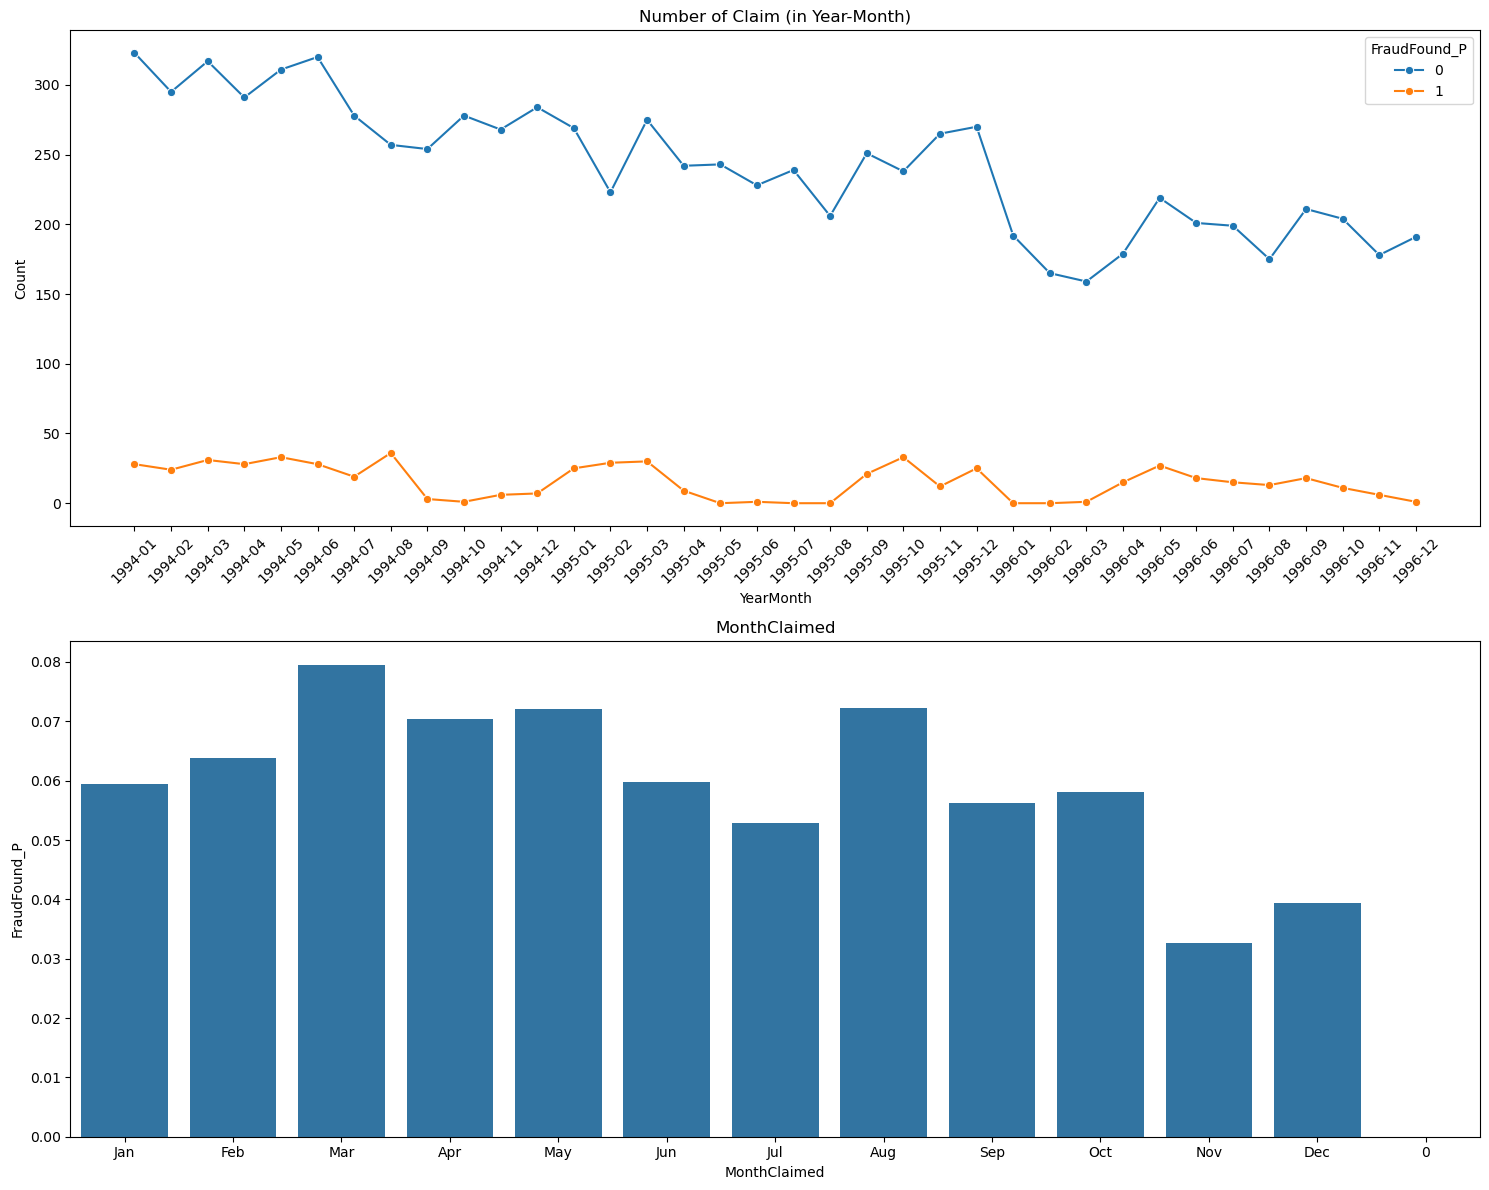

In [65]:
month_map = {'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6, 
             'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}

ts_df = eda_df.copy()
ts_df['Month_Num'] = ts_df['Month'].map(month_map)
ts_df['MonthClaimed_Num'] = ts_df['MonthClaimed'].map(month_map)

# Menggunakan unstack() dan stack() agar bulan dengan 0 kasus fraud tetap tercatat sebagai 0 (tidak diskip)
ts_incident = ts_df.groupby(['Year', 'Month_Num', 'FraudFound_P']).size().unstack(fill_value=0).stack().reset_index(name='Count')

# Menggabungkan Year dan Month_Num menjadi format string YearMonth (contoh: 1994-01)
ts_incident['YearMonth'] = ts_incident['Year'].astype(str) + '-' + ts_incident['Month_Num'].astype(str).str.zfill(2)

# Mengurutkan data agar garis waktu berurutan dengan benar
ts_incident = ts_incident.sort_values(['Year', 'Month_Num'])

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Visualisasi Tren Kejadian Kecelakaan dari Waktu ke Waktu
sns.lineplot(data=ts_incident, x='YearMonth', y='Count', hue='FraudFound_P', marker='o', ax=axes[0])
axes[0].set_title('Number of Claim (in Year-Month)')
axes[0].tick_params(axis='x', rotation=45)

# Visualisasi Musiman (Seasonality) Berdasarkan Bulan Klaim
order_list = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '0']
sns.barplot(data = eda_df,
            x = "MonthClaimed",
            y = "FraudFound_P",
            errorbar = None,
            order = order_list,
            ax = axes[1])
axes[1].set_title('MonthClaimed')

plt.tight_layout()
plt.show()

Dari hasil di atas dapat dilihat bahwa:
- Dari waktu ke waktu, banyaknya normal claim cenderung menurun.
- Dari waktu ke waktu, banyaknya fraudulent claim juga cukup stabil cenderung menurun, tetapi ada beberapa waktu di mana fraudulent claim mengalami lonjakan (seperti di awal dan akhir 1995).
- Berdasarkan bulannya, bulan Maret memiliki probabilitas tertinggi dan bulan November memiliki probabilitas terendah untuk fraudulent claim.
- Terdapat unknown category di MonthClaimed (MonthClaimed == '0')

### Visualizations for Categorical Variables

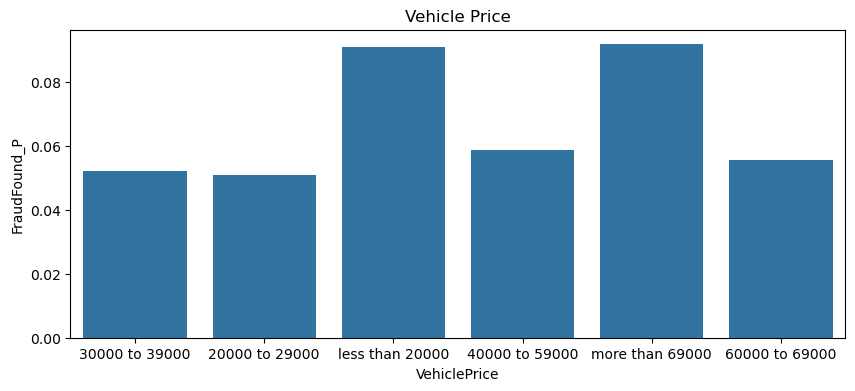

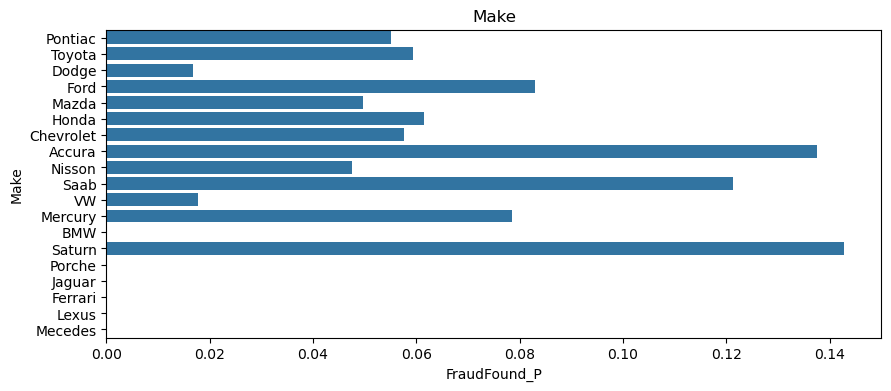

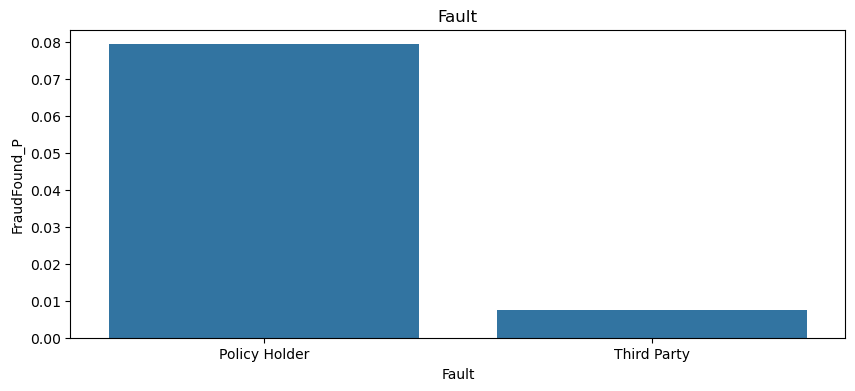

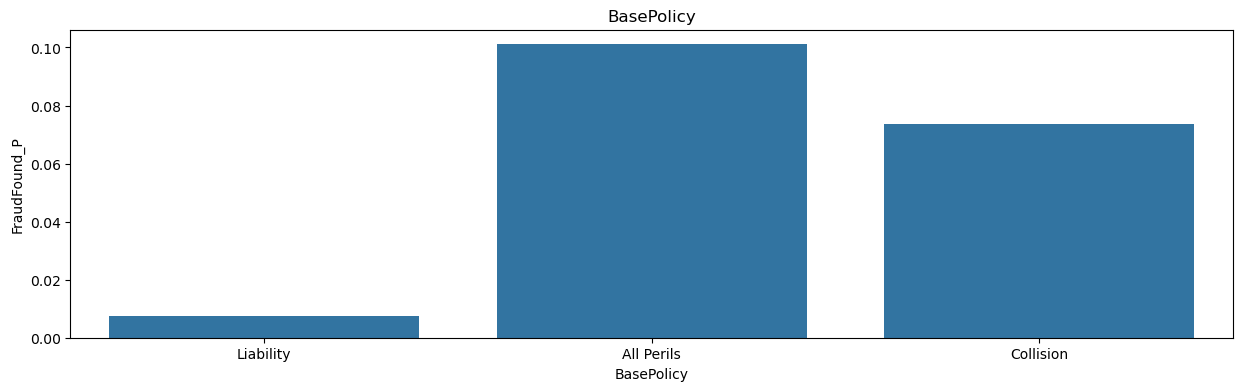

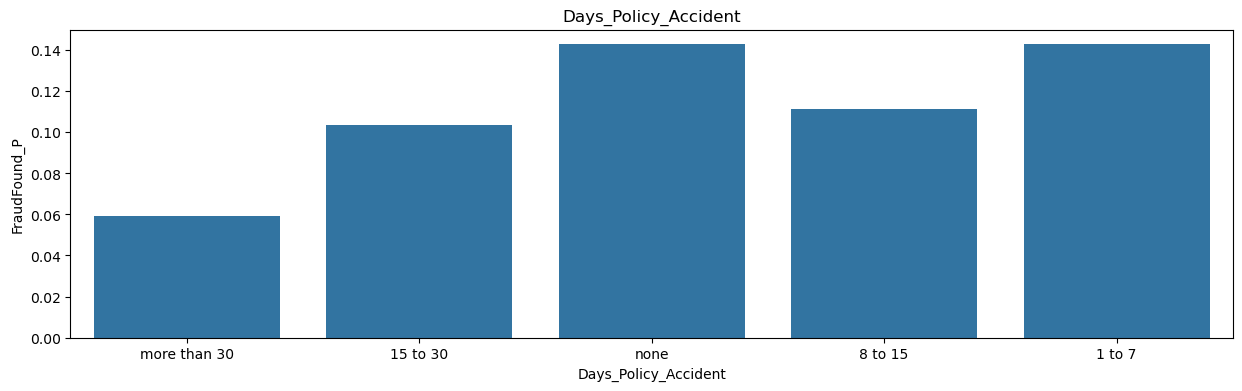

In [68]:
# Visualize the VehiclePrice
plt.figure(figsize = (10,4))
sns.barplot(data = eda_df,
            x = "VehiclePrice",
            y = "FraudFound_P",
            errorbar = None)

plt.title("Vehicle Price")
plt.show()

# Visualize the Make
plt.figure(figsize = (10,4))
sns.barplot(data = eda_df,
            y = "Make",
            x = "FraudFound_P",
            errorbar = None)

plt.title("Make")
plt.show()

# Visualize the Fault
plt.figure(figsize = (10,4))
sns.barplot(data = eda_df,
            x = "Fault",
            y = "FraudFound_P",
            errorbar = None)

plt.title("Fault")
plt.show()

# Visualize the BasePolicy
plt.figure(figsize = (15,4))
sns.barplot(data = eda_df,
            x = "BasePolicy",
            y = "FraudFound_P",
            errorbar = None)

plt.title("BasePolicy")
plt.show()

# Visualize the Days_Policy_Accident
plt.figure(figsize = (15,4))
sns.barplot(data = eda_df,
            x = "Days_Policy_Accident",
            y = "FraudFound_P",
            errorbar = None)

plt.title("Days_Policy_Accident")
plt.show()

Dari hasil di atas semakin memperkuat hasil dari pertanyaan sebelumnya bahwa:
- Kategori harga more than 69000 dan less than 20000 memiliki proporsi fraudulent claim tertinggi.
- Kendaraan yang bermerek Saab, Saturn, dan Accura memiliki proporsi fraudulent claim tertinggi, namun dari soal sebelumnya, dapat dilihat bahwa frekuensi mereka jauh lebih sedikit dibandingkan Pontiac, Toyota, Honda (tiga merek dengan frekuensi terbanyak).
- Proporsi fraudulent claim untuk Policy Holder 10 kali lipat lebih tinggi daripada Third Party.
- Proporsi fraudulent claim untuk polis Liability jauh lebih kecil dibandingkan jenis polis lainnya.
- Secara proporsi, fraudulent claim untuk kategori more than 30 lebih kecil dibandingkan kategori lainnya, meskipun frekuensinya paling banyak dibandingkan kategori lainnya.

## Question 4

Our goal is to determine how big is the company's loss when fraud occurs, we will examine the loss. Suppose we have some experts that can evaluate the fraudulent loss by using this formula: \
$$
\text{Expected Fraudulent Loss}=\text{PolicyType Weight} \times \text{Avg VehiclePrice} \times \text{DriverRating Weight}
$$

|PolicyType|Weight|
|:--|:--|
|Sedan - Collision|0.9|
|Sedan - Liability|0.8|
|Sedan - All Perils|1.1|
|Sport - Collision|1.2|
|Sport - Liability|1.1|
|Sport - All Perils|1.3|
|Utility - Collision|1.2|
|Utility - Liability|0.8|
|Utility - All Perils|0.95|

|DriverRating|Weight|
|:--|:--|
|1|0.8|
|2|0.7|
|3|0.6|
|4|0.5|

|VehiclePrice|Avg VehiclePrice|
|:--|:--|
|less than 100|100|
|100 - 300|(300 + 100) / 2|
|more than 300|300|

Further Reading on PolicyType
- [Liability Coverage](https://www.allstate.com/resources/what-is-liability-coverage)
- [Perils Coverage](https://www.allstate.com/resources/home-insurance/perils)
- [Collision Coverage](https://www.allstate.com/resources/car-insurance/what-is-collision-insurance)

Create a column `ExpFraudLoss` and calculate the value using the formula above

In [72]:
label = {'PolicyType':{'Sedan - Collision'   :0.9,
                       'Sedan - Liability'   :0.8,
                       'Sedan - All Perils'  :1.1,
                       'Sport - Collision'   :1.2,
                       'Sport - Liability'   :1.1,
                       'Sport - All Perils'  :1.3,
                       'Utility - Collision' :1.2,
                       'Utility - Liability' :0.8,
                       'Utility - All Perils':0.95,},
         'DriverRating':{1:0.8,
                         2:0.7,
                         3:0.6,
                         4:0.5},
         'VehiclePrice':{'less than 20000':20_000,
                         '20000 to 29000' :(29_000+20_000)/2,
                         '30000 to 39000' :(39_000+30_000)/2,
                         '40000 to 59000' :(59_000+40_000)/2,
                         '60000 to 69000' :(69_000+60_000)/2,
                         'more than 69000':69_000}}

In [73]:
def make_ExpFraudLoss(X):
    """
    Make new column, ExpFraudLoss

    Parameters
    ----------
    X : pd.DataFrame
        The input data

    Returns
    -------
    X : pd.DataFrame
        The input data with ExpFraudLoss column
        
    """
    PolicyType_Weight = X['PolicyType'].map(label['PolicyType'])
    DriverRating_Weight = X['DriverRating'].map(label['DriverRating'])
    Avg_VehiclePrice = X['VehiclePrice'].map(label['VehiclePrice'])
    X['ExpFraudLoss'] = PolicyType_Weight * DriverRating_Weight * Avg_VehiclePrice
    return X

In [74]:
# Make new columns for eda_df
eda_df = make_ExpFraudLoss(eda_df)
eda_df

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,FraudFound_P,ExpFraudLoss
2839,Jan,1,Tuesday,Pontiac,Urban,Thursday,Jan,1,Male,Married,...,No,No,External,more than 5,no change,1 vehicle,1994,Liability,0,19320.0
5783,Mar,2,Friday,Pontiac,Urban,Friday,Mar,2,Male,Married,...,No,No,External,none,no change,1 vehicle,1994,All Perils,0,18865.0
10425,Jan,1,Tuesday,Pontiac,Rural,Monday,Jan,2,Male,Married,...,No,No,External,none,no change,1 vehicle,1995,Collision,0,10800.0
10966,Jan,1,Thursday,Toyota,Urban,Wednesday,Jan,2,Male,Married,...,No,No,External,none,no change,1 vehicle,1995,Liability,0,13720.0
14520,Jul,2,Sunday,Dodge,Rural,Tuesday,Jul,2,Female,Single,...,No,No,External,more than 5,no change,1 vehicle,1996,Liability,0,13720.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11935,Oct,4,Monday,Ford,Urban,Tuesday,Oct,4,Female,Married,...,No,No,External,more than 5,no change,1 vehicle,1996,Liability,0,16560.0
12067,Jan,1,Wednesday,Pontiac,Urban,Wednesday,Jan,1,Male,Married,...,No,No,External,1 to 2,no change,1 vehicle,1996,Collision,0,15435.0
14159,Jan,1,Thursday,Chevrolet,Urban,Friday,Jan,2,Male,Single,...,No,No,External,none,no change,1 vehicle,1996,Liability,0,16560.0
2829,Sep,1,Friday,Chevrolet,Urban,Friday,Sep,1,Male,Married,...,No,No,External,none,no change,3 to 4,1994,Liability,0,33120.0


In [75]:
# Sanity check (null value in ExpFraudLoss)
eda_df['ExpFraudLoss'].isnull().sum()

0

In [76]:
# Make new columns for X_train
X_train = make_ExpFraudLoss(X_train)
X_train

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,ExpFraudLoss
2839,Jan,1,Tuesday,Pontiac,Urban,Thursday,Jan,1,Male,Married,...,51 to 65,No,No,External,more than 5,no change,1 vehicle,1994,Liability,19320.0
5783,Mar,2,Friday,Pontiac,Urban,Friday,Mar,2,Male,Married,...,36 to 40,No,No,External,none,no change,1 vehicle,1994,All Perils,18865.0
10425,Jan,1,Tuesday,Pontiac,Rural,Monday,Jan,2,Male,Married,...,36 to 40,No,No,External,none,no change,1 vehicle,1995,Collision,10800.0
10966,Jan,1,Thursday,Toyota,Urban,Wednesday,Jan,2,Male,Married,...,51 to 65,No,No,External,none,no change,1 vehicle,1995,Liability,13720.0
14520,Jul,2,Sunday,Dodge,Rural,Tuesday,Jul,2,Female,Single,...,31 to 35,No,No,External,more than 5,no change,1 vehicle,1996,Liability,13720.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11935,Oct,4,Monday,Ford,Urban,Tuesday,Oct,4,Female,Married,...,51 to 65,No,No,External,more than 5,no change,1 vehicle,1996,Liability,16560.0
12067,Jan,1,Wednesday,Pontiac,Urban,Wednesday,Jan,1,Male,Married,...,51 to 65,No,No,External,1 to 2,no change,1 vehicle,1996,Collision,15435.0
14159,Jan,1,Thursday,Chevrolet,Urban,Friday,Jan,2,Male,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1996,Liability,16560.0
2829,Sep,1,Friday,Chevrolet,Urban,Friday,Sep,1,Male,Married,...,31 to 35,No,No,External,none,no change,3 to 4,1994,Liability,33120.0


In [77]:
# Sanity check (null value in ExpFraudLoss)
X_train['ExpFraudLoss'].isnull().sum()

0

In [78]:
# Make new columns for X_valid
X_valid = make_ExpFraudLoss(X_valid)
X_valid

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,ExpFraudLoss
13829,Mar,2,Friday,Mazda,Urban,Friday,Mar,2,Male,Married,...,51 to 65,No,No,External,none,no change,1 vehicle,1996,Liability,16560.0
6974,Mar,2,Friday,Ford,Urban,Tuesday,Apr,1,Female,Married,...,41 to 50,No,No,External,more than 5,no change,1 vehicle,1995,Collision,34830.0
14783,Dec,2,Sunday,Mazda,Urban,Monday,Dec,3,Male,Married,...,36 to 40,No,No,External,none,no change,1 vehicle,1996,All Perils,21560.0
8888,Sep,1,Tuesday,Pontiac,Urban,Thursday,Sep,2,Male,Married,...,31 to 35,No,No,External,more than 5,no change,1 vehicle,1995,Collision,15435.0
7083,Feb,2,Saturday,Chevrolet,Urban,Wednesday,Feb,4,Male,Married,...,41 to 50,No,No,External,more than 5,no change,1 vehicle,1995,Liability,22080.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12962,Feb,1,Tuesday,Mazda,Urban,Tuesday,Feb,1,Male,Single,...,26 to 30,No,No,External,more than 5,no change,1 vehicle,1996,Collision,57960.0
103,Jan,1,Thursday,Mazda,Urban,Tuesday,Jan,2,Male,Married,...,41 to 50,No,No,External,more than 5,no change,1 vehicle,1994,All Perils,16170.0
5712,May,4,Saturday,Toyota,Urban,Wednesday,Jun,1,Male,Single,...,51 to 65,No,No,External,1 to 2,2 to 3 years,2 vehicles,1994,All Perils,15400.0
11575,Dec,3,Monday,Mazda,Rural,Wednesday,Dec,4,Male,Single,...,31 to 35,No,No,External,1 to 2,no change,1 vehicle,1996,Collision,11025.0


In [79]:
# Sanity check (null value in ExpFraudLoss)
X_valid['ExpFraudLoss'].isnull().sum()

0

In [80]:
# Make new columns for X_valid
X_test = make_ExpFraudLoss(X_test)
X_test

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,ExpFraudLoss
2497,Aug,5,Monday,Mazda,Rural,Friday,Sep,1,Male,Single,...,31 to 35,No,No,External,3 to 5,no change,1 vehicle,1994,Collision,24840.0
9707,Aug,5,Monday,Chevrolet,Urban,Tuesday,Aug,5,Male,Married,...,36 to 40,No,No,External,more than 5,no change,1 vehicle,1995,Liability,13800.0
4989,Dec,3,Tuesday,Toyota,Rural,Wednesday,Dec,4,Male,Married,...,36 to 40,No,No,External,more than 5,no change,1 vehicle,1994,Liability,19320.0
13894,Jan,3,Tuesday,Toyota,Urban,Monday,Feb,2,Male,Married,...,51 to 65,No,No,External,none,no change,1 vehicle,1996,All Perils,16170.0
15288,Jun,2,Tuesday,Toyota,Urban,Friday,Jun,4,Male,Married,...,51 to 65,No,No,External,none,1 year,2 vehicles,1996,All Perils,11000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2436,Mar,5,Wednesday,Toyota,Rural,Friday,May,1,Male,Single,...,31 to 35,No,No,External,1 to 2,4 to 8 years,2 vehicles,1994,All Perils,18865.0
10295,Jan,1,Monday,Honda,Urban,Tuesday,Jan,1,Male,Married,...,36 to 40,No,No,External,none,no change,1 vehicle,1995,Liability,9800.0
5339,Jan,2,Saturday,Toyota,Urban,Monday,Jan,2,Male,Married,...,36 to 40,No,No,External,3 to 5,no change,1 vehicle,1994,Collision,17640.0
4796,Nov,3,Monday,Mazda,Urban,Tuesday,Nov,4,Male,Married,...,31 to 35,No,No,External,3 to 5,no change,1 vehicle,1994,All Perils,13475.0


In [81]:
# Sanity check (null value in ExpFraudLoss)
X_test['ExpFraudLoss'].isnull().sum()

0

## Question 5

Perform exploratory data analysis using variable `ExpFraudLoss`, find the distribution, relationship with other variables, and descriptive statistics measurement on this feature. Explain the insights related to the fraudulent detection.

### Descriptive Statistics

In [85]:
desc_stats = eda_df.groupby('FraudFound_P')['ExpFraudLoss'].describe()
for col in desc_stats.columns:
    if col == 'count':
        desc_stats[col] = desc_stats[col].apply(lambda x: f"{x:,.0f}")
    else:
        desc_stats[col] = desc_stats[col].apply(lambda x: f"${x:,.2f}")

print(desc_stats.T)

print("\nTotal ExpFraudLoss")
print(eda_df.groupby('FraudFound_P')['ExpFraudLoss'].sum().apply(lambda x: f"${x:,.2f}"))

FraudFound_P           0           1
count              8,698         554
mean          $20,300.01  $24,053.67
std           $11,284.43  $13,953.56
min            $8,000.00  $10,800.00
25%           $13,475.00  $14,400.00
50%           $16,170.00  $18,630.00
75%           $22,080.00  $27,506.25
max           $71,760.00  $66,240.00

Total ExpFraudLoss
FraudFound_P
0    $176,569,510.00
1     $13,325,732.50
Name: ExpFraudLoss, dtype: object


### Visualizations for ExpFraudLoss Distribution

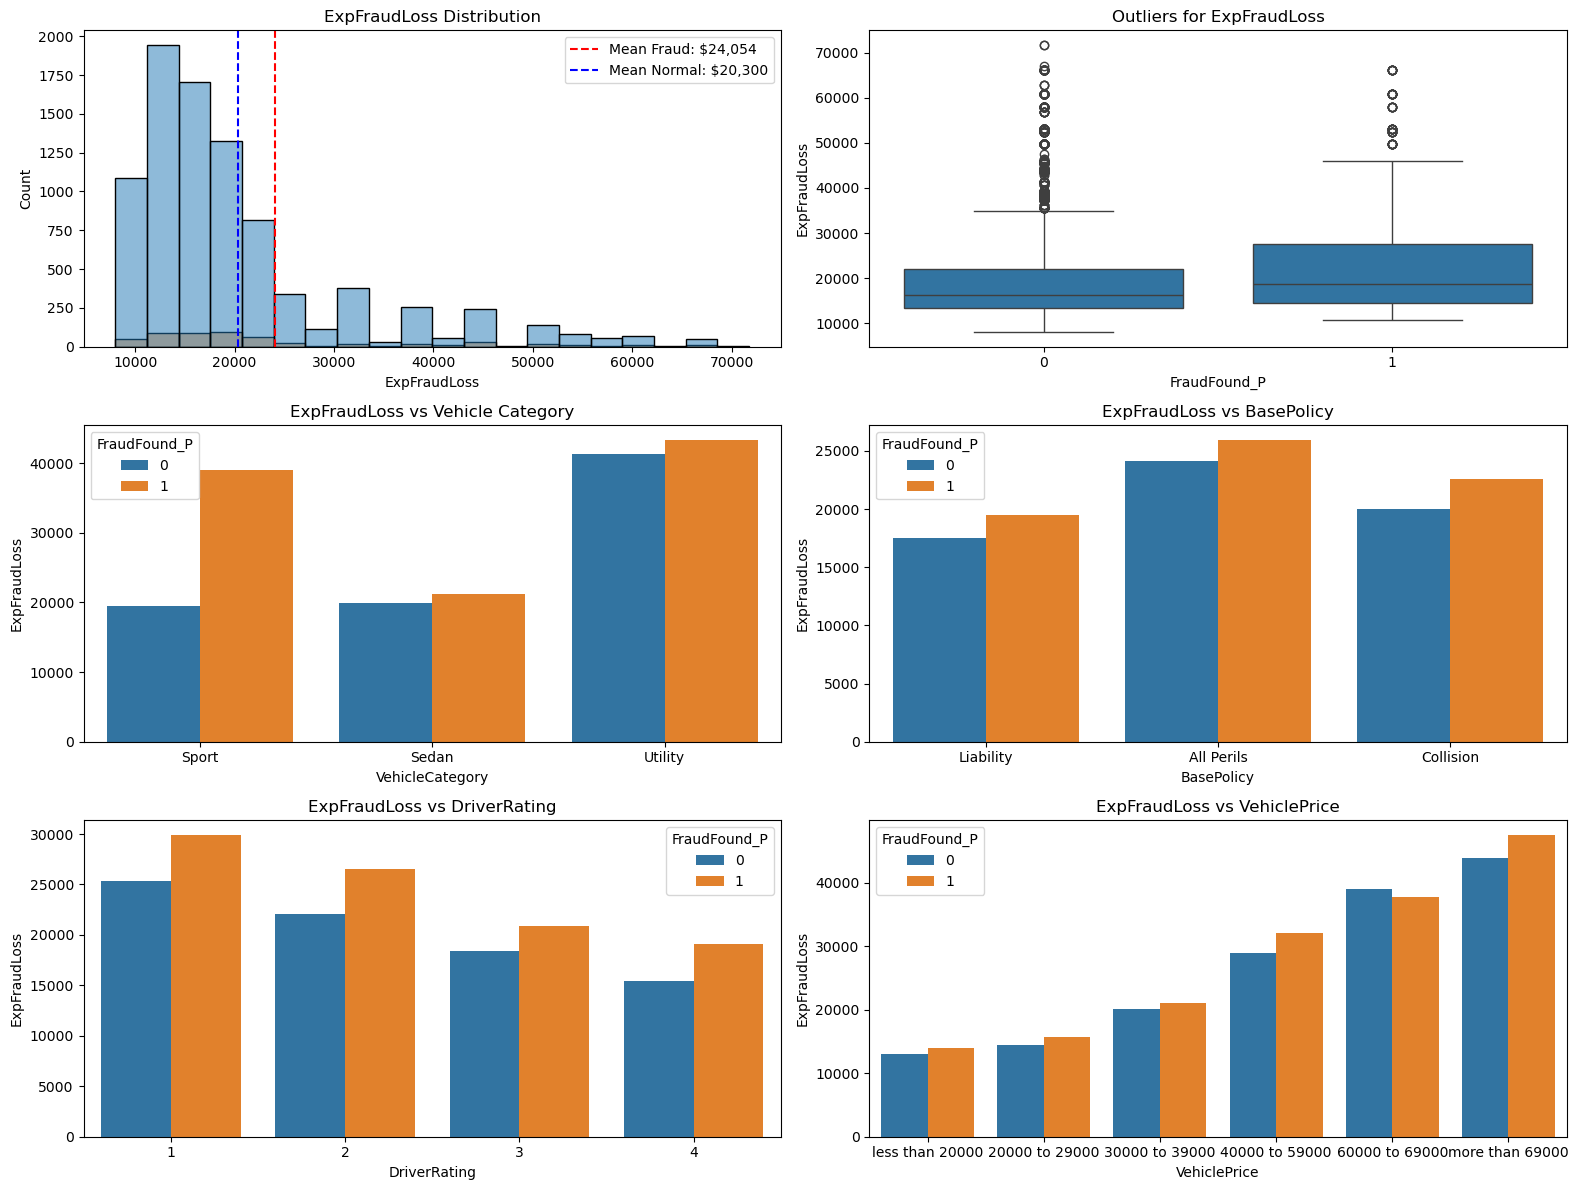

In [87]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Plot 1: Histogram Distribusi ExpFraudLoss
sns.histplot(data=eda_df, 
             x='ExpFraudLoss', 
             hue='FraudFound_P', 
             bins=20, 
             ax=axes[0, 0])
axes[0, 0].set_title('ExpFraudLoss Distribution')

# Menambahkan garis rata-rata pada Histogram
fraud_loss_mean = eda_df[eda_df["FraudFound_P"] == 1]["ExpFraudLoss"].mean()
normal_loss_mean = eda_df[eda_df["FraudFound_P"] == 0]["ExpFraudLoss"].mean()
axes[0, 0].axvline(fraud_loss_mean, color='red', linestyle='dashed', label=f'Mean Fraud: ${fraud_loss_mean:,.0f}')
axes[0, 0].axvline(normal_loss_mean, color='blue', linestyle='dashed', label=f'Mean Normal: ${normal_loss_mean:,.0f}')
axes[0, 0].legend()

# Plot 2: Boxplot untuk melihat Outliers
sns.boxplot(data=eda_df, 
            x='FraudFound_P', 
            y='ExpFraudLoss', 
            ax=axes[0, 1])
axes[0, 1].set_title('Outliers for ExpFraudLoss')

# Plot 3: ExpFraudLoss vs Vehicle Category
sns.barplot(data=eda_df, 
            x='VehicleCategory', 
            y='ExpFraudLoss', 
            hue='FraudFound_P', 
            ax=axes[1, 0],
            errorbar = None)
axes[1, 0].set_title('ExpFraudLoss vs Vehicle Category')

# Plot 4: ExpFraudLoss vs BasePolicy
sns.barplot(data=eda_df, 
            x='BasePolicy', 
            y='ExpFraudLoss', 
            hue='FraudFound_P', 
            ax=axes[1, 1],
            errorbar = None)
axes[1, 1].set_title('ExpFraudLoss vs BasePolicy')


# Plot 5: ExpFraudLoss vs DriverRating
sns.barplot(data=eda_df, 
            x='DriverRating', 
            y='ExpFraudLoss', 
            hue='FraudFound_P', 
            ax=axes[2,0],
            errorbar = None)
axes[2,0].set_title('ExpFraudLoss vs DriverRating')

# Plot 6: ExpFraudLoss vs VehiclePrice
price_order = [
    'less than 20000', '20000 to 29000', '30000 to 39000', 
    '40000 to 59000', '60000 to 69000', 'more than 69000']

sns.barplot(data=eda_df, 
            x='VehiclePrice', 
            y='ExpFraudLoss', 
            hue='FraudFound_P', 
            order=price_order, 
            ax=axes[2,1],
            errorbar = None)
axes[2,1].set_title('ExpFraudLoss vs VehiclePrice')

plt.tight_layout()
plt.show()

Dari hasil di atas, dapat dilihat bahwa:
- Rata-rata ExpFraudLoss untuk fraudulent claim ($24,054) lebih tinggi daripada rata-rata ExpFraudLoss untuk normal claim ($20,300).
- Nilai minimum, Q1, median, dan Q3 dari ExpFraudLoss untuk fraudulent claim juga lebih tinggi dari normal claim.
- Besarnya ExpFraudLoss untuk fraudulent claim jauh lebih tinggi dibandingkan untuk normal claim di kategori Sport. Hal ini berbeda dengan dua kategori lainnya yang memiliki proporsi yang mirip antara fraudulent dan normal claim.
- Proporsi ExpFraudLoss antara fraudulent dan normal claim untuk tiap kategori cukup mirip, All Perils memiliki nilai ExpFraudLoss terbesar.
- ExpFraudLoss berkorelasi negatif dengan DriverRating; DriverRating yang lebih bagus memiliki rata-rata ExpFraudLoss yang lebih kecil.
- ExpFraudLoss berkorelasi positif dengan VehiclePrice; VehiclePrice yang lebih mahal memiliki rata-rata ExpFraudLoss yang lebih besar.

## Question 6

Create 2 models, evaluate the performance of model, and simulate the cost of making false prediction
- Create a **baseline model** and **expert based model** (using if-else statement based on exploration data analysis in question 3 and 5) to predict (detect) the fraudulent cases. Evaluate the baseline model using evaluation metrics and ROC/AUC. Make simulation based on this condition:
|Cost Variables|Cost|
|:--|:--|
|Cost of ignoring fraudulent case|Corresponding `ExpFraudLoss` amount per fraud case|
|Cost of handling false fraudulent case| $\$$300 (acquisition cost)|
||$\$$700 (profit loss)|

- Create table summary of the evaluation
|Models|Accuracy|Recall|Precision|ROC/AUC|Cost|
|:--|:--|:--|:--|:--|:--|
|Baseline||||||					
|Expert Based Model||||||

### Creating Class and Functions

- Based on exploration data analysis in question 3 and 5, it is defined that a transaction is categorized as **fraud**
  IF:
  - Fault is Policy Holder, AND
  - Base Policy is Collision or All Perils, AND
  - Satisfy either:
    - Vehicle Price is more than 69000 or less than 20000 OR
    - Vehicle Category is Sport OR
    - Driver Rating is 1
    
- We can create model to flag according to the expert rules.

In [93]:
# Create a model
class ExpertBased:
    """
    Flag fraud using expert rules
    The rules:
        - if `Fault` is "Policy Holder", AND
             `BasePolicy` is "All Perils" or "Collision", AND
             satisfy either:
                 - Vehicle Price is "more than 69000" or "less than 20000" OR
                 - Vehicle Category is "Sport" OR
                 - Driver Rating is 1
          then return 1 (fraud)
        - else return 0 (not fraud)
    """
    def fit(self, X, y):
        # Fitting the model
        # No need to do anyting
        pass

    def predict(self, X):
        # Predict using the expert rules
        cond_fault = (X['Fault'] == "Policy Holder")
        cond_policy = (X['BasePolicy'].isin(['Collision', 'All Perils']))
        cond_price = (X['VehiclePrice'].isin(['more than 69000', 'less than 20000']))
        cond_category = (X['VehicleCategory'] == 'Sport')
        cond_rating = (X['DriverRating'] == 1)
        y_pred = (cond_fault & cond_policy & (cond_price | cond_category | cond_rating)).astype(int)

        return y_pred

In [94]:
# Create a function to summarize prediction results
def cross_tab(y_act, y_pred):
    """
    Summarize the prediction results

    Parameters
    ----------
    y_act : array-like
        The true target (y actual)

    y_pred : array-like
        The predicted

    Return
    ------
    crosstab_table : pd.DataFrame
        The crosstab table (confusion matrix)
        [[TP, FN],
         [FP, TN]]
    """
    # Extract the prediction
    fp = np.sum((y_act == 0) & (y_pred == 1))  # False positive
    tp = np.sum((y_act == 1) & (y_pred == 1))  # True positive
    fn = np.sum((y_act == 1) & (y_pred == 0))  # False negative
    tn = np.sum((y_act == 0) & (y_pred == 0))  # True negative

    # Summarize
    crosstab_table = pd.DataFrame(
        data = [[tp, fn], [fp, tn]],
        columns = ["Predicted Fraud", "Predicted Non Fraud"],
        index = ["Actual Fraud", "Actual Non Fraud"]
    )

    return crosstab_table

In [95]:
# Function to calculate the accuracy
def accuracy(eval_table):
    """
    Calculate the accuracy of the model

    Parameters
    ----------
    eval_table : {array-like} of shape (n_class,n_class)
        Evaluation table, where `n_class` is the number of class

    Returns
    --------
    acc: float
        The accuracy of the model
    """
    # define the correct prediction in each class
    tp = eval_table.loc["Actual Fraud", "Predicted Fraud"]
    tn = eval_table.loc["Actual Non Fraud", "Predicted Non Fraud"]

    # define the false prediction in each class
    fp = eval_table.loc["Actual Non Fraud", "Predicted Fraud"]
    fn = eval_table.loc["Actual Fraud", "Predicted Non Fraud"]

    # Accuracy = n_correct / n_total
    n_correct = tp + tn
    n_false = tp + tn + fp + fn
    acc = n_correct / n_false

    return  acc


In [96]:
# Function to calculate recall
def recall(eval_table):
    """
    Calculate the recall of the model

    Parameters
    ----------
    eval_table : {array-like} of shape (n_class,n_class)
        Evaluation table, where `n_class` is the number of class

    Returns
    --------
    recall: float
        The recall of the model
    """
    # define the number of correct prediction and the prediction of fraud
    tp = eval_table.loc["Actual Fraud", "Predicted Fraud"]
    fn = eval_table.loc["Actual Fraud", "Predicted Non Fraud"]

    # Recall = n_correct_positive / n_actual_positive
    n_actual_positive = tp + fn
    n_correct_positive = tp
    recall = n_correct_positive / n_actual_positive

    return recall


In [97]:
# Function to calculate the precision
def precision(eval_table):
    """
    Calculate the precision of the model

    Parameters
    ----------
    eval_table : {array-like} of shape (n_class,n_class)
        Evaluation table, where `n_class` is the number of class

    Returns
    --------
    precision: float
        The precision of the model
    """
    # define the number of correct prediction and the prediction of fraud
    tp = eval_table.loc["Actual Fraud", "Predicted Fraud"]
    fp = eval_table.loc["Actual Non Fraud", "Predicted Fraud"]

    # precision = n_correct_positive / n_predicted_positive
    n_predicted_positive = tp + fp
    n_correct_positive = tp
    precision = n_correct_positive / (n_predicted_positive + 1e-6)  # add 1e-6 to prevent 0 division

    return precision

In [98]:
def roc_auc(y_true, y_score, dx=0.001):
    """
    Function to count auc
    (Reference: https://mmuratarat.github.io/2019-10-01/how-to-compute-AUC-plot-ROC-by-hand)

    Parameters
    ----------
    y_true : {array-like} of shape (n_sample, )
        The dependent or response variable

    y_score: {array-like} of shape (n_sample, )
        The success probability of X

    dx     : float
        The difference between thresholds

    Returns
    -------
    auc       : float
        The value of ROC-AUC (area under the ROC curve)
        
    """
    y_true = y_true.reset_index(drop=True)
    if not isinstance(y_score, np.ndarray):
        y_score = y_score.reset_index(drop=True)
    # false positive rate
    FPR = []
    # true positive rate
    TPR = []
    # Iterate thresholds from 0.0 to 1.0
    thresholds = np.arange(0.0, 1.0001, dx)
    
    # get number of success (1) and failure (0) in the dataset
    P = sum(y_true) # success
    N = len(y_true) - P # failure
    
    # iterate through all thresholds and determine fraction of true positives and false positives found at this threshold
    for thresh in thresholds:
        FP=0
        TP=0
        thresh = round(thresh,3) #Limiting floats to three decimal points
        for i in range(len(y_score)):
            if (y_score[i] >= thresh):
                if y_true[i] == 1:
                    TP = TP + 1
                if y_true[i] == 0:
                    FP = FP + 1
        FPR.append(FP/N)
        TPR.append(TP/P)

    # this is the AUC
    auc = -1 * np.trapz(TPR, FPR) # Trapezoidal rule is used. Since you're integrating from right to left, this flips the sign of the result

    return auc

- This metric assume:
  - Average cost of ignoring fraudulent cases: Corresponding `ExpFraudLoss` amount per fraud case
  - Average cost of handling false fraudulent case:
    - \$300 as acquisition cost and
    - \$700 as profit loss

- So the formula will be

$$
\text{cost} = \left(\text{fp} \times (\$ 300 + \$ 700)\right) + \left(\text{fn} \times \text{ExpFraudLoss}\right)
$$

In [101]:
# Calculate the loss from false prediction
def loss(eval_table, df, y_true, y_pred):
    """
    Calculate the business-side cost of the model

    Parameters
    ----------
    eval_table : {array-like} of shape (n_class,n_class)
        Evaluation table, where `n_class` is the number of class
    df         : Pandas DataFrame
        The data input
    y_true     : Pandas Series
        The data actual output
    y_pred     : numpy.ndarray
        The data predicted output

    Returns
    --------
    cost: float
        The total cost according to business assumptions
    """
    # Get the number of false negative and false positive
    fp = eval_table.loc["Actual Non Fraud", "Predicted Fraud"]

    # Define cost
    cost_acquired = 300     # average cost to acquire new user
    cost_profit = 700       # average cost of profit loss

    # Calculate the total cost
    fn_cost = df.loc[(y_true == 1) & (y_pred == 0), 'ExpFraudLoss'].sum()
    fp_cost = fp * (cost_acquired + cost_profit)
    cost = fn_cost + fp_cost

    return cost


In [102]:
def model_summary(model, model_name, X, y):
    # Given a model, predict X, then return evaluation on y
    y_pred = model.predict(X)

    # Get the eval table
    eval_table = cross_tab(y, y_pred)

    # Find all metrics
    accuracy_ = accuracy(eval_table)
    recall_ = recall(eval_table)
    precision_ = precision(eval_table)
    auc_ = roc_auc(y_true = y,
                   y_score = y_pred)
    cost_ = loss(eval_table = eval_table,
                 df = X,
                 y_true = y,
                 y_pred = y_pred)

    # Get into dataframe
    summary = pd.DataFrame(
        [[accuracy_, recall_, precision_, auc_, cost_]],
        columns = ["Accuracy", "Recall", "Precision", "ROC/AUC", "Business Cost ($)"],
        index = [model_name]
    )

    return summary

### Train Set
___

In [104]:
# Create model
base_clf = DummyClassifier(strategy = "most_frequent")

# Fit
base_clf.fit(X_train, y_train)

# Evaluate
summary_baseline = model_summary(model = base_clf,
                               model_name = "Baseline",
                               X = X_train,
                               y = y_train)
summary_baseline

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Baseline,0.940121,0.0,0.0,0.5,13325732.5


In [105]:
# Create model
expert_clf = ExpertBased()

# Fit
expert_clf.fit(X_train, y_train)

# Evaluate
summary_expert = model_summary(model = expert_clf,
                               model_name = "Expert Based Model",
                               X = X_train,
                               y = y_train)
summary_expert

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Expert Based Model,0.795071,0.463899,0.13847,0.597391,6774557.5


In [106]:
# Add to summary evaluation train
summary_evaluation_train = pd.concat((summary_baseline, summary_expert),
                                     axis=0)
summary_evaluation_train

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Baseline,0.940121,0.000000,0.00000,0.500000,13325732.5
Expert Based Model,0.795071,0.463899,0.13847,0.597391,6774557.5


Dari hasil di atas, dapat dilihat bahwa:
- Meskipun baseline memiliki nilai accuracy lebih tinggi, bukan berarti dia lebih baik dalam mendeteksi fraud.
- Untuk memprediksi kasus fraud yang real, Expert Based Model lebih baik performanya, dapat dilihat dari nilai recall, dia dapat memprediksi 464 kasus fraud dari 1000 kasus fraud.
- Namun, dari 1000 kasus yang diprediksi akan fraud, dari nilai precision, Expert Based Model hanya dapat memprediksi 138 kasus dengan benar.
- Dari nilai ROC-AUC, Expert Based Model hanya memiliki nilai AUC 0,597. Artinya, model ini tidak terlalu mampu membedakan antara kelas positif (Fraud) dan kelas negatif (Normal). Namun, hal ini wajar karena Expert Based Model menghasilkan prediksi biner yang diskrit (0 atau 1), bukan nilai probabilitas kontinu.
- Namun, dalam performa bisnis, business cost dari Expert Based Model hampir dua kali lipat lebih rendah dari Baseline Model.
- Tapi, ini baru dilihat performa untuk train set, kita harus memvalidasinya di validation set.

### Validation Set
___

In [109]:
# Summary baseline
summary_base_valid = model_summary(model = base_clf,
                                   model_name = "Baseline",
                                   X = X_valid,
                                   y = y_valid)

summary_evaluation_valid = summary_base_valid.copy()
summary_evaluation_valid

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Baseline,0.940013,0.0,0.0,0.5,4415840.0


In [110]:
# Summary expert-based
summary_expert_valid = model_summary(model = expert_clf,
                                     model_name = "Expert Based Model",
                                     X = X_valid,
                                     y = y_valid)

# Add to summary evaluation valid
summary_evaluation_valid = pd.concat((summary_evaluation_valid, summary_expert_valid),
                                     axis=0)
summary_evaluation_valid

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Baseline,0.940013,0.000000,0.000000,0.500000,4415840.0
Expert Based Model,0.789883,0.486486,0.139969,0.601466,2195365.0


Dari sini, dapat dilihat bahwa:
- Hasil performa untuk validation set mirip dengan train set.
- Artinya, Expert Based Model lebih baik dalam mendeteksi fraud dibanding Baseline model karena dapat meminimalkan business cost menjadi dua kali lipat lebih rendah.
- Kita akan membandingkannya lagi dengan dua model lain di pertanyaan selanjutnya, lalu kita akan memilih model terbaik di antara empat model tersebut.

## Question 7

- Perform fraud detection using 2 Statistical Approach (IQR and Z-score method) using numerical variables as X. Make cost simulation just like the Question 6 point one and create a table summary of evaluation
|Models|Accuracy|Recall|Precision|ROC/AUC|Cost|
|:--|:--|:--|:--|:--|:--|
|Baseline||||||					
|Expert Based Model||||||
|Statistical Approach: IQR||||||
|Statistical Approach: Z-Score||||||

- Evaluate and compare all the models, write your insights on how you will decide which model that you want to propose as the fraud detection model.

### Creating Class and Functions

In [115]:
class IQRThreshold:
    """
    Flag fraud using IQR threshold
    """
    def fit(self, X, y):
        # Here we calculate the IQR of column ExpFraudLoss
        # Select col
        X = X["ExpFraudLoss"].copy()

        # Extract Q1, Q3, and then IQR
        q1 = np.quantile(X, 0.25)
        q3 = np.quantile(X, 0.75)
        iqr = q3-q1

        # Obtain the threshold
        self.threshold = q3 + (1.5*iqr)

    def predict(self, X):
        # Predict using the given threshold
        y_pred = (X["ExpFraudLoss"] > self.threshold).astype(int)

        return y_pred

In [116]:
class ZscoreThreshold:
    """
    Flag fraud using Z-score threshold
    """
    def fit(self, X, y):
        # Here we calculate the mean and standard deviation of column ExpFraudLoss
        # Select col
        X = X["ExpFraudLoss"].copy()

        # Extract mean and standard deviation
        self.mean = X.mean()
        self.std = X.std()

        # Set the threshold (in this case, we set threshold = 2 to make significance level alpha = 2.28%
        self.threshold = 2

    def predict(self, X):
        # Predict using the given threshold
        z_scores = (X["ExpFraudLoss"] - self.mean) / self.std
        y_pred = (z_scores > self.threshold).astype(int)

        return y_pred

### Train Set
___

In [118]:
# Create model
IQR_clf = IQRThreshold()

# Fit
IQR_clf.fit(X_train, y_train)

# Evaluate
summary_IQR = model_summary(model = IQR_clf,
                            model_name = "Statistical Approach: IQR",
                            X = X_train,
                            y = y_train)

# Add to summary evaluation train
summary_evaluation_train = pd.concat((summary_evaluation_train, summary_IQR),
                                     axis=0)
summary_evaluation_train

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Baseline,0.940121,0.000000,0.000000,0.500000,13325732.5
Expert Based Model,0.795071,0.463899,0.138470,0.597391,6774557.5
Statistical Approach: IQR,0.845763,0.211191,0.105691,0.536667,8653982.5


In [119]:
# Create model
Zscore_clf = ZscoreThreshold()

# Fit
Zscore_clf.fit(X_train, y_train)

# Evaluate
summary_Zscore = model_summary(model = Zscore_clf,
                               model_name = "Statistical Approach: Z-Score",
                               X = X_train,
                               y = y_train)

# Add to summary evaluation train
summary_evaluation_train = pd.concat((summary_evaluation_train, summary_Zscore),
                                     axis=0)
summary_evaluation_train

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Baseline,0.940121,0.000000,0.000000,0.500000,13325732.5
Expert Based Model,0.795071,0.463899,0.138470,0.597391,6774557.5
Statistical Approach: IQR,0.845763,0.211191,0.105691,0.536667,8653982.5
Statistical Approach: Z-Score,0.883701,0.137184,0.112760,0.529501,9896187.5


Dari hasil di atas, dapat dilihat bahwa:
- Expert Based Model tetap menjadi model yang terbaik dalam mendeteksi fraud karena:
  - Untuk memprediksi kasus fraud yang real, dapat dilihat dari nilai recall yang paling tinggi, Expert Based Model dapat memprediksi 464 kasus fraud dari 1000 kasus fraud.
  - Dari nilai precision, Expert Based Model juga memiliki nilai yang paling tinggi dari yang lain meskipun hanya dapat memprediksi 138 kasus dengan benar dari 1000 kasus yang diprediksi akan fraud.
  - Dari nilai ROC-AUC, Expert Based Model juga memiliki nilai AUC tertinggi yaitu 0,597 meskipun masih cukup rendah. Artinya, model ini tidak terlalu mampu membedakan antara kelas positif (Fraud) dan kelas negatif (Normal).
  - Dalam performa bisnis, business cost dari Expert Based Model memiliki performa terbaik, hampir dua kali lipat lebih rendah dari Baseline Model.
- Tapi, ini baru dilihat performa untuk train set, kita harus memvalidasinya di validation set.

### Validation Set
___

In [122]:
# Summary IQR statistics-based
summary_IQR_valid = model_summary(model = IQR_clf,
                                  model_name = "Statistical Approach: IQR",
                                  X = X_valid,
                                  y = y_valid)

# Add to summary evaluation valid
summary_evaluation_valid = pd.concat((summary_evaluation_valid, summary_IQR_valid),
                                     axis=0)
summary_evaluation_valid

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Baseline,0.940013,0.000000,0.000000,0.500000,4415840.0
Expert Based Model,0.789883,0.486486,0.139969,0.601466,2195365.0
Statistical Approach: IQR,0.844358,0.183784,0.093664,0.524720,3019060.0


In [123]:
# Summary Z-Score statistics-based
summary_Zscore_valid = model_summary(model = Zscore_clf,
                                     model_name = "Statistical Approach: Z-Score",
                                     X = X_valid,
                                     y = y_valid)

# Add to summary evaluation valid
summary_evaluation_valid = pd.concat((summary_evaluation_valid, summary_Zscore_valid),
                                     axis=0)
summary_evaluation_valid

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Baseline,0.940013,0.000000,0.000000,0.500000,4415840.0
Expert Based Model,0.789883,0.486486,0.139969,0.601466,2195365.0
Statistical Approach: IQR,0.844358,0.183784,0.093664,0.524720,3019060.0
Statistical Approach: Z-Score,0.889105,0.135135,0.120773,0.531936,3219820.0


Dari sini, dapat dilihat bahwa:
- Hasil performa untuk validation set mirip dengan train set.
- Artinya, Expert Based Model masih menjadi model paling baik dalam mendeteksi fraud dibanding model lainnya karena dapat meminimalkan business cost menjadi dua kali lipat lebih rendah.
- Kita akan menggunakan Expert Based Model ini untuk Test Set.

### Test Set
___

In [126]:
# Summary expert-based
summary_best = model_summary(model = expert_clf,
                             model_name = "Expert Based - VALID",
                             X = X_valid,
                             y = y_valid)
summary_best

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Expert Based - VALID,0.789883,0.486486,0.139969,0.601466,2195365.0


In [127]:
# Summary expert-based
summary_expert_test = model_summary(model = expert_clf,
                                    model_name = "Expert Based - TEST",
                                    X = X_test,
                                    y = y_test)
summary_best = pd.concat((summary_best, summary_expert_test), axis=0)
summary_best

,Accuracy,Recall,Precision,ROC/AUC,Business Cost ($)
Expert Based - VALID,0.789883,0.486486,0.139969,0.601466,2195365.0
Expert Based - TEST,0.792153,0.434783,0.129660,0.584550,2327825.0


Dari sini, dapat dilihat bahwa:
- Hasil performa untuk test set mirip dengan validation set meskipun business cost-nya 6% lebih tinggi dari validation set.

## Question 8

- You proposed a fraud detection model to minimize fraud losses. However, beyond cost savings, you must also consider benefits, model ownership costs, and fraud handling costs. **ROI** is calculated as the ratio of net profit (benefit minus costs) to total investment, expressed as a percentage. \
$$
\text{ROI} = \frac{\text{Total Utility}}{\text{Total cost of ownership} + \text{Total cost of fraud handling}}
$$
 
- **Total utility** is defined as the difference between benefits and costs, representing the net return. 
    - Costs are as follows:
       - False Negatives (FN): Fraud loss, represented by the `ExpFraudLoss` amount for ignored fraud cases.
       - False Positives (FP): Losses from profit and customer acquisition costs, including $\$$300 for acquisition and $\$$700 for profit loss per false positive.
    - **Benefits** include:
       - True Positives (TP): Prevented fraud losses, represented by `ExpFraudLoss`.
       - True Negatives (TN): Generated profit of $\$$700 from legitimate transactions.
- The **total cost of ownership** consists of acquisition costs ($\$$500,000 for software, hardware, security, and development) and operation costs ($\$$500,000 for migration, setup, monitoring, and support).
- **Total Cost of Fraud Handling** includes inspection and legal costs. Assume:
    - Fraud handling cost per claim: Varies by vehicle category
       - Sedan: $\$$6,000
       - Sport: $\$$8,000
       - Utility: $\$$4,000
    - Legal cost: $\$$50,000

### **1. Total Utility**

In [132]:
# Make prediction
y_pred_test = expert_clf.predict(X_test)

# Get the eval table
eval_table_test = cross_tab(y_test, y_pred_test)

# Show the result of prediction
eval_table_test

,Predicted Fraud,Predicted Non Fraud
Actual Fraud,80,104
Actual Non Fraud,537,2363


In [133]:
# define the correct prediction in each class
tp = eval_table_test.loc["Actual Fraud", "Predicted Fraud"]
tn = eval_table_test.loc["Actual Non Fraud", "Predicted Non Fraud"]

# define the false prediction in each class
fp = eval_table_test.loc["Actual Non Fraud", "Predicted Fraud"]
fn = eval_table_test.loc["Actual Fraud", "Predicted Non Fraud"]

- Let's simulate this metric, assume
  - Average cost of fraudulent cases: Corresponding `ExpFraudLoss` amount per fraud case
  - Average cost to acquire new user: \$300/user
  - Average potential profit: \$700/user

In [135]:
cost = loss(eval_table = eval_table_test, 
            df = X_test, 
            y_true = y_test, 
            y_pred = y_pred_test)
cost

2327825.0

In [136]:
# Calculate the total benefit
# Define benefit
benefit_profit = 700       # average potential profit

# Calculate the total benefit
tp_benefit = X_test.loc[(y_test == 1) & (y_pred_test == 1), 'ExpFraudLoss'].sum()
tn_benefit = tn * benefit_profit
benefit = tp_benefit + tn_benefit
benefit

3909195.0

Calculate the total utility as substraction Benefit and Cost as representation of total return.
- Cost is in negative form since it's the amount we should lose in return we use the model
- Benefit is in positive form since it's the amount we can get in return we use the model

In [138]:
# Calculate the total utility
total_utility = benefit - cost
total_utility

1581370.0

### **2. Total Cost of Ownership**

- The details of component we need to calculate the total cost of ownership depends on the company and industry
- In this section, assume the cost of ownership we have comes from
  - Acquisition Costs (software, hardware cost, network and security cost, model developer cost): `$500,000`
  - Operation Costs (Model Migration, Setup, Monitoring, and Support Costs): `$500,000`

In [141]:
# Calculate the total cost of ownership
acq_cost = 500000
op_cost = 500000

total_cost_of_ownership = acq_cost + op_cost
total_cost_of_ownership

1000000

### **3. Total Cost of Fraud Handling**

- The total cost of fraud handling include inspection costs, legal costs.
- We assume:
  - Cost of fraud handling: Varies by vehicle category
       - Sedan: $\$$6,000
       - Sport: $\$$8,000
       - Utility: $\$$4,000
  - Legal cost: \$50,000

In [144]:
# Calculate the total cost of Fraud Handling
vehicle = X_test.loc[(y_test == 1) & (y_pred_test == 1),"VehicleCategory"].value_counts()
vhc_cat = {"Sedan":6000,
           "Sport":8000,
           "Utility":4000}
ins_cost = 0
for cat in vhc_cat:
    vhc_cost = vehicle.get(cat, 0)*vhc_cat[cat]
    ins_cost += vhc_cost

legal_cost = 50000
total_cost_of_fraud_handling = ins_cost + legal_cost
total_cost_of_fraud_handling

532000

### **4. Calculate ROI**

In [146]:
roi = (total_utility/(total_cost_of_ownership + total_cost_of_fraud_handling))*100
roi

103.22258485639686

The Return of Investment of Expert Based model is 103.22%